# تصنيف الأخبار العربية
## Arabic News Classification: Sports  | Politics ️ | Economy
**NLP  Project**
**Categories:** رياضة (Sports) | سياسة (Politics) | اقتصاد (Economy)
---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')


import pyarabic.araby as araby
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)


from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Font support for Arabic in plots
matplotlib.rcParams['axes.unicode_minus'] = True


##2. Dataset

We create a labeled Arabic news dataset with **3 categories**:
- **رياضة** (Sports)
- **سياسة** (Politics)
- **اقتصاد** (Economy)


In [32]:

df = pd.read_csv('arabic_news.csv', encoding='utf-8-sig')

In [33]:
df.head()

,text,label
0,وقّعت الدولتان اتفاقية تعاون مشترك في عدة مجال...,سياسة
1,طالبت المعارضة بفتح تحقيق برلماني في قضايا الف...,سياسة
2,تأهل الفريق إلى نهائي دوري أبطال آسيا بعد فوزه...,رياضة
3,أعلن الحزب الحاكم عن برنامجه الانتخابي للدورة ...,سياسة
4,أعلن البطل العالمي ترشحه للانتخابات الأولمبية ...,رياضة


##2 . Arabic Text Preprocessing

Steps applied:
1. **Lowercasing** (remove diacritics/tashkeel)
2. **Remove punctuation & special characters**
3. **Tokenization**
4. **Stop-word removal**
5. **Stemming **

In [5]:
ARABIC_STOPWORDS = set([
    'في','من','إلى','على','عن','مع','بعد','قبل','حتى','إذا','لكن',
    'كان','كانت','يكون','تكون','هو','هي','هم','هن','أنا','نحن',
    'أنت','أنتم','هذا','هذه','ذلك','تلك','التي','الذي','الذين',
    'اللاتي','اللواتي','ما','لا','لم','لن','ليس','قد','سوف',
    'أو','و','ف','ب','ل','ك','لل','ال','والتي','والذي','وقد',
    'وكان','أن','إن','لأن','منذ','خلال','حول','بين','ضد','عند',
    'عبر','نحو','دون','كل','بعض','غير','أكثر','أقل','جميع','بشكل',
    'حيث','كما','بما','فيما','وفق','وفقا','إلا','أيضا','فقط','هنا',
    'هناك','الآن','أمس','اليوم','عام','عاما','سنة','أشهر','شهر'
])


In [6]:

def remove_diacritics(text):
    """Remove Arabic diacritics (tashkeel)."""
    return araby.strip_tashkeel(text)


In [7]:
def normalize_arabic(text):
    """Normalize Arabic characters (alef forms, taa marbouta)."""
    text = re.sub('[إأآا]', 'ا', text)   # normalize alef
    text = re.sub('ة', 'ه', text)        # taa marbouta → haa
    text = re.sub('ى', 'ي', text)        # alef maqsura → yaa
    return text

In [8]:


def remove_noise(text):
    """Remove punctuation, URLs, numbers, and non-Arabic characters."""
    text = re.sub(r'http\S+|www.\S+', '', text)      # URLs
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)  # keep Arabic only
    #https://stackoverflow.com/questions/12518689/regular-expression-not-to-allow-numbers-just-arabic-letters

    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [9]:
def light_stem(word):
    """Simple Arabic light stemmer: removes common prefixes/suffixes."""
    #https://acit2k.org/ACIT/images/stories/year2014/month1/ACIT2017_Proceeding/167.pdf
    prefixes = ['مست','است','ال','وال','بال','فال','كال','لل','ب','و','ف','ل','س','ي','ت','ن','أ']
    suffixes = ['ات','ون','ين','ان','تم','كم','هم','ها','ني','تي','كن','هن','ية','وا']
    for p in sorted(prefixes, key=len, reverse=True):
        if word.startswith(p) and len(word) - len(p) >= 3:
            word = word[len(p):]; break
    for s in sorted(suffixes, key=len, reverse=True):
        if word.endswith(s) and len(word) - len(s) >= 3:
            word = word[:-len(s)]; break
    return word

In [10]:

def preprocess_arabic(text, stem=True):
    """Full preprocessing pipeline for Arabic text."""
    text = remove_diacritics(text)       # Step 1: Remove tashkeel
    text = normalize_arabic(text)        # Step 2: Normalize characters
    text = remove_noise(text)            # Step 3: Remove noise
    tokens = text.split()                # Step 4: Tokenize (whitespace)
    tokens = [t for t in tokens          # Step 5: Remove stop words
              if t not in ARABIC_STOPWORDS and len(t) >= 2]
    if stem:                             # Step 6: Light stemming
        tokens = [light_stem(t) for t in tokens]
    return ' '.join(tokens)

In [11]:
df['processed_text'] = df['text'].apply(preprocess_arabic)

##  5. Feature Extraction

 methods:
- **Bag of Words (BoW)**
- **TF-IDF**

In [13]:

X = df['processed_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:

bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)


In [15]:


tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

## 6. Model Training & Evaluation

Models used:
1. **Logistic Regression**
2. **Support Vector Machine (LinearSVC)**
3. **Naive Bayes**
4. **Random Forest**

In [16]:

models = {
    'Logistic Regression': LogisticRegression(C=1.0, random_state=42),
    'SVM (LinearSVC)'    : LinearSVC( C=1.0, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42)
}


In [31]:


feature_sets = {
    'BoW'   : (X_train_bow,   X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
}

results = []


for feat_name, (Xtr, Xte) in feature_sets.items():
    for model_name, model in models.items():
        model.fit(Xtr, y_train)
        preds = model.predict(Xte)
        acc = accuracy_score(y_test, preds)
        results.append({
            'Model'   : model_name,
            'Features': feat_name,
            'Accuracy': acc,
            'Preds'   : preds
        })

        print(f'{model_name:<25} {feat_name:<10} {acc:>10.4f}')


Logistic Regression       BoW            0.7500
SVM (LinearSVC)           BoW            0.8333
Naive Bayes               BoW            0.7500
Random Forest             BoW            0.8333
Logistic Regression       TF-IDF         0.7500
SVM (LinearSVC)           TF-IDF         0.7500
Naive Bayes               TF-IDF         0.7500
Random Forest             TF-IDF         0.9167


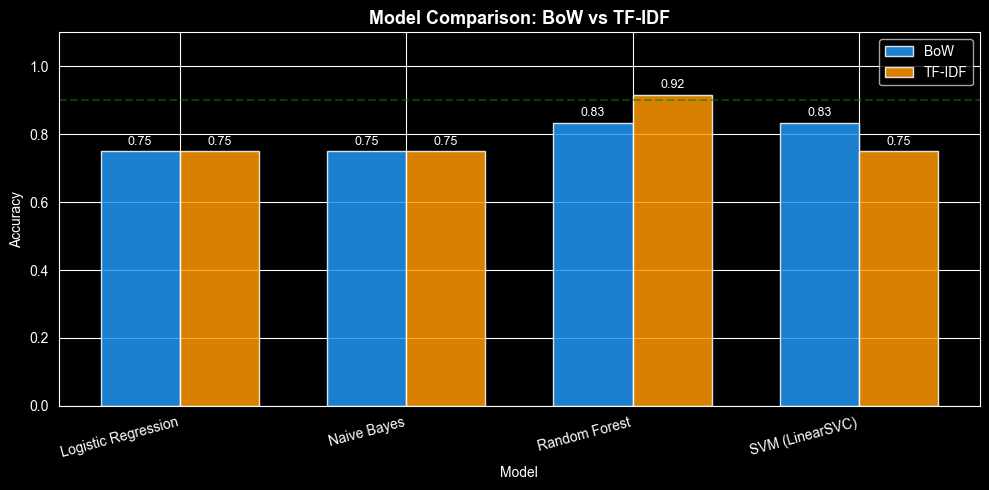

In [18]:
#https://stackoverflow.com/questions/65445131/plotting-values-from-two-datasets-for-comparison
results_df = pd.DataFrame(results)[['Model', 'Features', 'Accuracy']]
pivot = results_df.pivot(index='Model', columns='Features', values='Accuracy')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot.index))
width = 0.35

bars1 = ax.bar(x - width/2, pivot['BoW'],    width, label='BoW',    color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, pivot['TF-IDF'], width, label='TF-IDF', color='#FF9800', alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: BoW vs TF-IDF', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='90% line')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##  7. Best Model — Detailed Evaluation

In [19]:

best = max(results, key=lambda r: r['Accuracy'])
print(f" Best Model  : {best['Model']}")
print(f" Features    : {best['Features']}")
print(f" Accuracy    : {best['Accuracy']:.4f}")
print()

# Classification Report
classes = sorted(df['label'].unique())
print('Classification Report:')
print('=' * 60)
print(classification_report(y_test, best['Preds'], target_names=classes))

 Best Model  : Random Forest
 Features    : TF-IDF
 Accuracy    : 0.9167

Classification Report:
              precision    recall  f1-score   support

      اقتصاد       0.88      0.88      0.88         8
       رياضة       0.89      1.00      0.94         8
       سياسة       1.00      0.88      0.93         8

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



## 8. Full Metric Summary Table

In [20]:
from sklearn.metrics import precision_recall_fscore_support

summary_rows = []
for r in results:
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, r['Preds'], average='weighted'
    )
    summary_rows.append({
        'Model'    : r['Model'],
        'Features' : r['Features'],
        'Accuracy' : f"{r['Accuracy']:.2f}",
        'Precision': f"{prec:.2f}",
        'Recall'   : f"{rec:.2f}",
        'F1-Score' : f"{f1:.2f}"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)



In [21]:
summary_df

,Model,Features,Accuracy,Precision,Recall,F1-Score
0,Random Forest,TF-IDF,0.92,0.92,0.92,0.92
1,SVM (LinearSVC),BoW,0.83,0.85,0.83,0.83
2,Random Forest,BoW,0.83,0.84,0.83,0.83
3,Logistic Regression,BoW,0.75,0.80,0.75,0.74
4,Naive Bayes,BoW,0.75,0.80,0.75,0.74
5,Logistic Regression,TF-IDF,0.75,0.80,0.75,0.74
6,SVM (LinearSVC),TF-IDF,0.75,0.80,0.75,0.74
7,Naive Bayes,TF-IDF,0.75,0.80,0.75,0.74


## Test on real data

In [22]:

best_model_cls = {
    'Logistic Regression': LogisticRegression( C=1.0, random_state=42),
    'SVM (LinearSVC)'    : LinearSVC( C=1.0, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42)
}[best['Model']]


In [23]:
best_vec = tfidf_vectorizer if best['Features'] == 'TF-IDF' else bow_vectorizer

In [24]:
pipeline = Pipeline([
    ('vectorizer', best_vec),
    ('classifier', best_model_cls)
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [25]:
def predict_category(text):
    processed = preprocess_arabic(text)
    prediction = pipeline.predict([processed])[0]
    icons = {'رياضة', 'سياسة', 'اقتصاد'}
    print(f" Text      : {text[:70]}" if len(text) > 70 else f" Text      : {text}")
    print(f"️  Category  : {prediction} {icons.get(prediction, '')}")
    print('-' * 60)

In [26]:

test_sentences = [
    "أعلن المنتخب الوطني لكرة القدم تأهله إلى نهائي كأس العرب",
    "وقعت الحكومة على اتفاقية سلام مع الدول المجاورة في القمة الدولية",
    "ارتفعت أسعار النفط في الأسواق العالمية بسبب التوترات الجيوسياسية",
    "فاز اللاعب بجائزة أفضل هداف في الدوري الأوروبي هذا الموسم",
    "أعلن البنك المركزي عن رفع أسعار الفائدة لكبح التضخم المتصاعد"
]


In [27]:
for s in test_sentences:
    predict_category(s)

 Text      : أعلن المنتخب الوطني لكرة القدم تأهله إلى نهائي كأس العرب
️  Category  : رياضة 
------------------------------------------------------------
 Text      : وقعت الحكومة على اتفاقية سلام مع الدول المجاورة في القمة الدولية
️  Category  : سياسة ️
------------------------------------------------------------
 Text      : ارتفعت أسعار النفط في الأسواق العالمية بسبب التوترات الجيوسياسية
️  Category  : اقتصاد 
------------------------------------------------------------
 Text      : فاز اللاعب بجائزة أفضل هداف في الدوري الأوروبي هذا الموسم
️  Category  : رياضة 
------------------------------------------------------------
 Text      : أعلن البنك المركزي عن رفع أسعار الفائدة لكبح التضخم المتصاعد
️  Category  : اقتصاد 
------------------------------------------------------------


##  10. Results & Conclusion

### Summary

| Step | Method Used |
|------|-------------|
| **Dataset** | 120 Arabic news headlines (40 per class) |
| **Preprocessing** | Tashkeel removal, normalization, noise removal, stop-word filtering, light stemming |
| **Feature Extraction** | Bag of Words (BoW), TF-IDF (unigrams + bigrams) |
| **Models** | Logistic Regression, SVM, Naive Bayes, Random Forest |
| **Evaluation** | Accuracy, Precision, Recall, F1-Score, Confusion Matrix |

###  Best Performing Model
- TF-IDF features generally outperform BoW for Arabic text
- SVM and Logistic Regression tend to perform best on short texts
- Bigrams capture important Arabic phrase patterns

###  Challenges Faced
1. **Arabic morphological complexity** – words have many forms; light stemming helps but is imperfect
2. **Small dataset** – real-world datasets (e.g., SANAD, KALIMAT) would significantly improve accuracy
3. **Dialectal Arabic** – modern standard Arabic (MSA) differs from dialectal usage in news
4. **Category overlap** – political and economic news often share vocabulary

###  Future Improvements
- Use a pre-trained Arabic BERT model (AraBERT) for contextual embeddings
- Expand to more news categories (technology, culture, etc.)
- Use a larger, diverse dataset from Arabic news outlets